importing the dependencies

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split,cross_val_score,RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
import pickle

Data loading and understanding 

In [6]:
# read the csv data to a pandas dataframe
df= pd.read_csv("train.csv") 

initial inspection

In [7]:
df.shape

(800, 22)

In [8]:
df.head()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,...,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,...,m,?,no,no,India,no,2.255185,18 and more,Self,0
2,3,1,1,1,1,1,1,1,1,1,...,m,White-European,no,yes,United States,no,14.851484,18 and more,Self,1
3,4,0,0,0,0,0,0,0,0,0,...,f,?,no,no,United States,no,2.276617,18 and more,Self,0
4,5,0,0,0,0,0,0,0,0,0,...,m,?,no,no,South Africa,no,-4.777286,18 and more,Self,0


In [9]:
df.tail()

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,...,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
795,796,0,1,0,0,0,0,0,0,1,...,m,Hispanic,no,no,New Zealand,no,12.999501,18 and more,Self,0
796,797,0,1,1,0,0,1,0,1,1,...,m,White-European,no,no,Cyprus,no,13.561518,18 and more,Self,0
797,798,0,0,0,0,0,0,0,0,0,...,m,South Asian,yes,no,New Zealand,no,2.653177,18 and more,Self,0
798,799,0,0,0,0,0,0,0,0,0,...,f,?,no,no,Canada,no,9.069342,18 and more,Self,0
799,800,0,1,0,0,0,0,0,0,0,...,f,?,no,no,United Arab Emirates,yes,2.243304,18 and more,Self,0


In [10]:
#display all the columns of dataframe 
pd.set_option('display.max_columns',None)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               800 non-null    int64  
 1   A1_Score         800 non-null    int64  
 2   A2_Score         800 non-null    int64  
 3   A3_Score         800 non-null    int64  
 4   A4_Score         800 non-null    int64  
 5   A5_Score         800 non-null    int64  
 6   A6_Score         800 non-null    int64  
 7   A7_Score         800 non-null    int64  
 8   A8_Score         800 non-null    int64  
 9   A9_Score         800 non-null    int64  
 10  A10_Score        800 non-null    int64  
 11  age              800 non-null    float64
 12  gender           800 non-null    str    
 13  ethnicity        800 non-null    str    
 14  jaundice         800 non-null    str    
 15  austim           800 non-null    str    
 16  contry_of_res    800 non-null    str    
 17  used_app_before  800 non-nu

In [12]:
#age column datatype to integer
df["age"]= df["age"].astype(int)

In [13]:
df.head(2)

,ID,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,0,1,0,1,0,1,0,1,1,38,f,?,no,no,Austria,no,6.351166,18 and more,Self,0
1,2,0,0,0,0,0,0,0,0,0,0,47,m,?,no,no,India,no,2.255185,18 and more,Self,0


In [14]:
for col in df.columns:
    numerical_features=["ID","age","result"]
    if col not in numerical_features:
        print(col,df[col].unique())
        print("-"*50)

A1_Score [1 0]
--------------------------------------------------
A2_Score [0 1]
--------------------------------------------------
A3_Score [1 0]
--------------------------------------------------
A4_Score [0 1]
--------------------------------------------------
A5_Score [1 0]
--------------------------------------------------
A6_Score [0 1]
--------------------------------------------------
A7_Score [1 0]
--------------------------------------------------
A8_Score [0 1]
--------------------------------------------------
A9_Score [1 0]
--------------------------------------------------
A10_Score [1 0]
--------------------------------------------------
gender <StringArray>
['f', 'm']
Length: 2, dtype: str
--------------------------------------------------
ethnicity <StringArray>
[              '?',  'White-European', 'Middle Eastern ',        'Pasifika',
           'Black',          'Others',        'Hispanic',           'Asian',
         'Turkish',     'South Asian',          'Latino'

In [15]:
pd.set_option("display.max_rows",None)

In [16]:
for col in df.columns:
    numerical_features=["ID","age","result"]
    if col not in numerical_features:
        print(col,df[col].unique())
        print("-"*50)

A1_Score [1 0]
--------------------------------------------------
A2_Score [0 1]
--------------------------------------------------
A3_Score [1 0]
--------------------------------------------------
A4_Score [0 1]
--------------------------------------------------
A5_Score [1 0]
--------------------------------------------------
A6_Score [0 1]
--------------------------------------------------
A7_Score [1 0]
--------------------------------------------------
A8_Score [0 1]
--------------------------------------------------
A9_Score [1 0]
--------------------------------------------------
A10_Score [1 0]
--------------------------------------------------
gender <StringArray>
['f', 'm']
Length: 2, dtype: str
--------------------------------------------------
ethnicity <StringArray>
[              '?',  'White-European', 'Middle Eastern ',        'Pasifika',
           'Black',          'Others',        'Hispanic',           'Asian',
         'Turkish',     'South Asian',          'Latino'

In [17]:
#dropping id and age_desc column
df=df.drop(columns=["ID","age_desc","result"]) 

In [18]:
df.shape

(800, 19)

In [19]:
df.head(2)

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38,f,?,no,no,Austria,no,Self,0
1,0,0,0,0,0,0,0,0,0,0,47,m,?,no,no,India,no,Self,0


In [20]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'relation', 'Class/ASD'],
      dtype='str')

In [21]:
df["contry_of_res"].unique()

<StringArray>
[             'Austria',                'India',        'United States',
         'South Africa',               'Jordan',       'United Kingdom',
               'Brazil',          'New Zealand',               'Canada',
           'Kazakhstan', 'United Arab Emirates',            'Australia',
              'Ukraine',                 'Iraq',               'France',
             'Malaysia',             'Viet Nam',                'Egypt',
          'Netherlands',          'Afghanistan',                 'Oman',
                'Italy',        'AmericanSamoa',              'Bahamas',
         'Saudi Arabia',              'Ireland',                'Aruba',
            'Sri Lanka',               'Russia',              'Bolivia',
           'Azerbaijan',              'Armenia',               'Serbia',
             'Ethiopia',               'Sweden',              'Iceland',
            'Hong Kong',               'Angola',                'China',
              'Germany',             

In [22]:
#define the mapping dictionary for country names
mapping={
    "Viet Nam":"Vietnam",
    "AmericanSamoa":"United States",
    "Hong Kong":"China"
}

#replace the value in the country cloumns
df["contry_of_res"] = df["contry_of_res"].replace(mapping)

In [23]:
df["contry_of_res"].unique()

<StringArray>
[             'Austria',                'India',        'United States',
         'South Africa',               'Jordan',       'United Kingdom',
               'Brazil',          'New Zealand',               'Canada',
           'Kazakhstan', 'United Arab Emirates',            'Australia',
              'Ukraine',                 'Iraq',               'France',
             'Malaysia',              'Vietnam',                'Egypt',
          'Netherlands',          'Afghanistan',                 'Oman',
                'Italy',              'Bahamas',         'Saudi Arabia',
              'Ireland',                'Aruba',            'Sri Lanka',
               'Russia',              'Bolivia',           'Azerbaijan',
              'Armenia',               'Serbia',             'Ethiopia',
               'Sweden',              'Iceland',                'China',
               'Angola',              'Germany',                'Spain',
                'Tonga',             

In [24]:
# target class distrubution
df["Class/ASD"].value_counts()

Class/ASD
0    639
1    161
Name: count, dtype: int64

**Insights:**
1. missing values in  ethnicity & relation
2. age_desc column has only 1 unique value. so it is removed as it is not important for prediction 
3. fixed counutry name 
4. identified class imbalance in the target column

3. ***Eda***

In [25]:
df.shape

(800, 19)

In [26]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'relation', 'Class/ASD'],
      dtype='str')

In [27]:
df.head(2)

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38,f,?,no,no,Austria,no,Self,0
1,0,0,0,0,0,0,0,0,0,0,47,m,?,no,no,India,no,Self,0


In [28]:
df.describe()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,Class/ASD
count,800.000000,800.000000,800.000000,800.00000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,0.560000,0.530000,0.450000,0.41500,0.395000,0.303750,0.397500,0.508750,0.495000,0.617500,27.963750,0.201250
std,0.496697,0.499411,0.497805,0.49303,0.489157,0.460164,0.489687,0.500236,0.500288,0.486302,16.329827,0.401185
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000
25%,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.000000
50%,1.000000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,24.000000,0.000000
75%,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,35.250000,0.000000
max,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.000000,1.000000


***univariate analysis***

***numerical columns:***
- age
- result

In [29]:
#set the desired theme
sns.set_theme(style="darkgrid")

Distribution Plots

Mean: 27.96375
Median 24.0


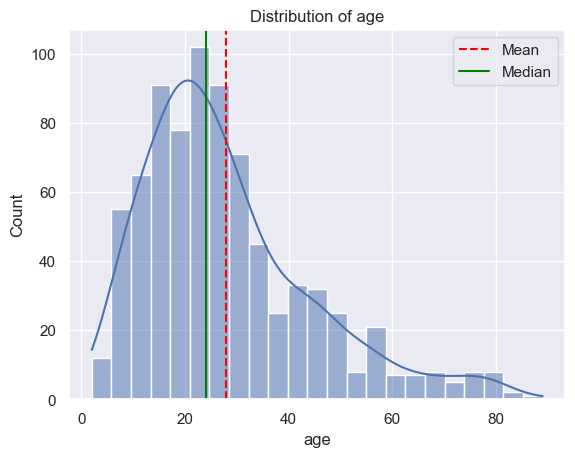

In [30]:
#histogram for "age "

sns.histplot(df["age"],kde=True)
plt.title("Distribution of age")

#calculate mean and median 
age_mean =df["age"].mean()
age_median =df["age"].median()
print("Mean:",age_mean)
print("Median",age_median)
#add vertical lines for mean and median
plt.axvline(age_mean,color="red",linestyle="--",label="Mean")
plt.axvline(age_median,color="green",linestyle="-",label="Median")
plt.legend()
plt.show()

In [31]:
#histogram for "result "

# sns.histplot(df["result"],kde=True)
# plt.title("Distribution of result")

# #calculate mean and median 
# result_mean =df["result"].mean()
# result_median =df["result"].median()
# print("Mean:",age_mean)
# print("Median",age_median)
# #add vertical lines for mean and median
# plt.axvline(result_mean,color="red",linestyle="--",label="Mean")
# plt.axvline(result_median,color="green",linestyle="-",label="Median")
# plt.legend()
# plt.show()

box plots for identifying outliers in the numerical column


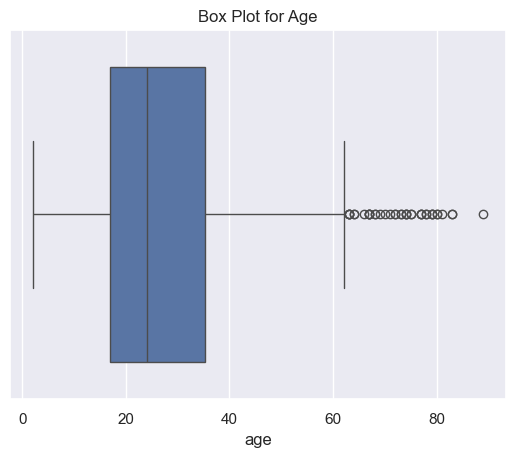

In [32]:
#box
sns.boxplot(x=df["age"])
plt.title("Box Plot for Age")
plt.xlabel("age")
plt.show()

In [33]:
#box
# sns.boxplot(x=df["result"])
# plt.title("Box Plot for result")
# plt.xlabel("result")
# plt.show()

In [34]:
 # count the outliers using iqr method   
Q1 = df["age"].quantile(0.25)
Q3 = df["age"].quantile(0.75)
IQR = Q3-Q1
lower_bound = Q1 -1.5*IQR
upper_bound = Q3+1.5*IQR
age_outliers =df[(df["age"]<lower_bound)|(df["age"]>upper_bound)]

In [35]:
len(age_outliers)

39

In [36]:
 # count the outliers using iqr method   
# Q1 = df["result"].quantile(0.25)
# Q3 = df["result"].quantile(0.75)
# IQR = Q3-Q1
# lower_bound = Q1 -1.5*IQR
# upper_bound = Q3+1.5*IQR
# result_outliers =df[(df["result"]<lower_bound)|(df["result"]>upper_bound)]

In [37]:
# len(result_outliers)

univariate analysis of categorical columns

In [38]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'relation', 'Class/ASD'],
      dtype='str')

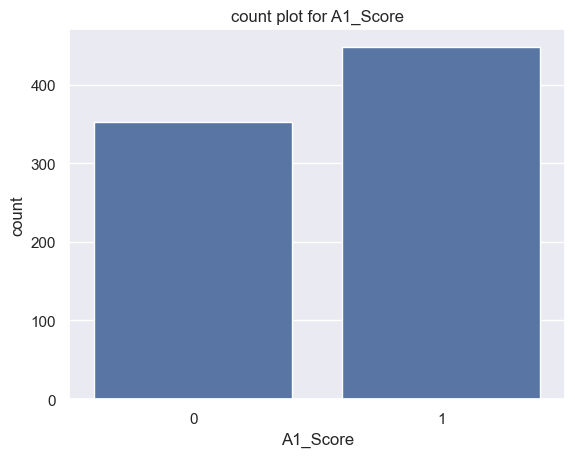

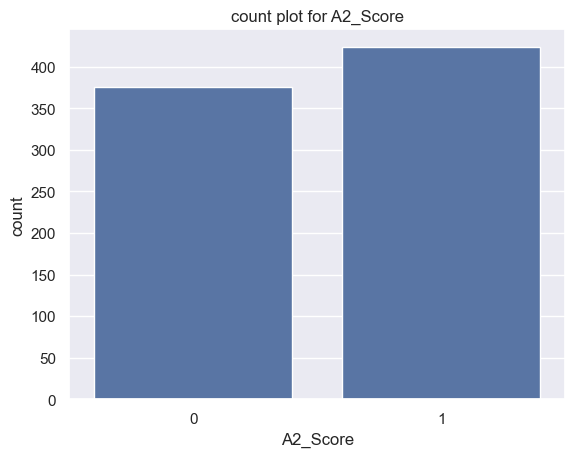

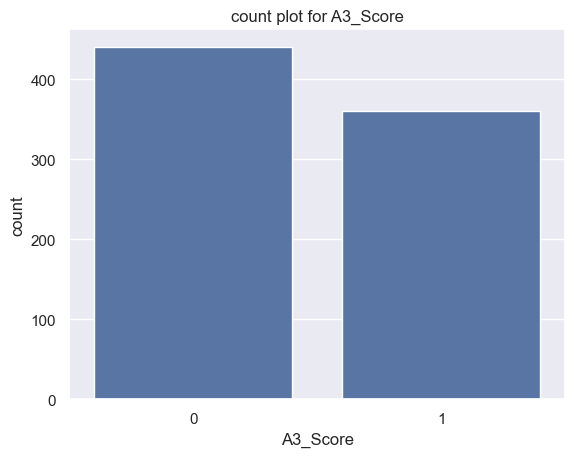

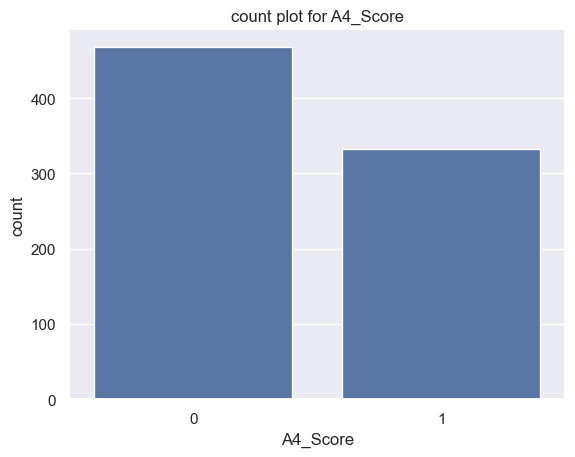

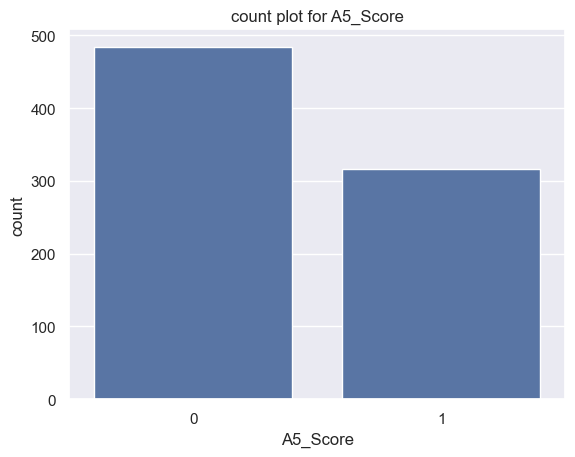

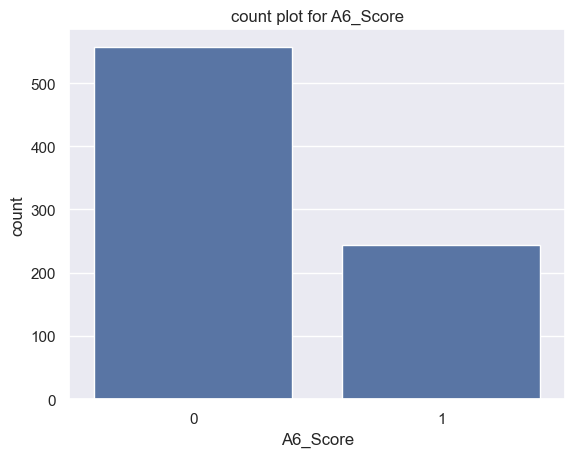

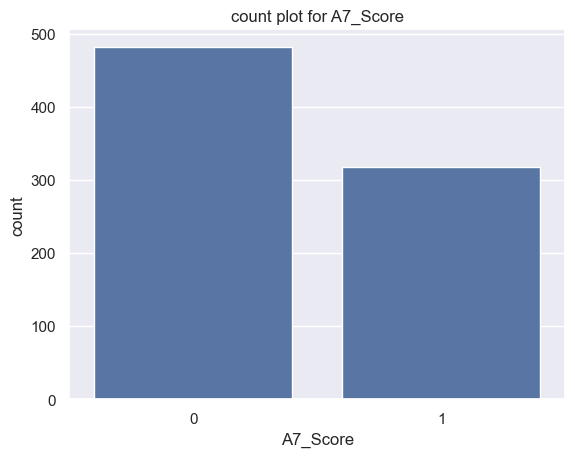

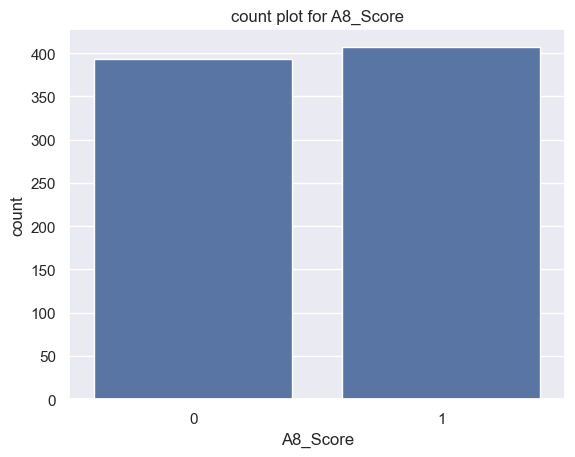

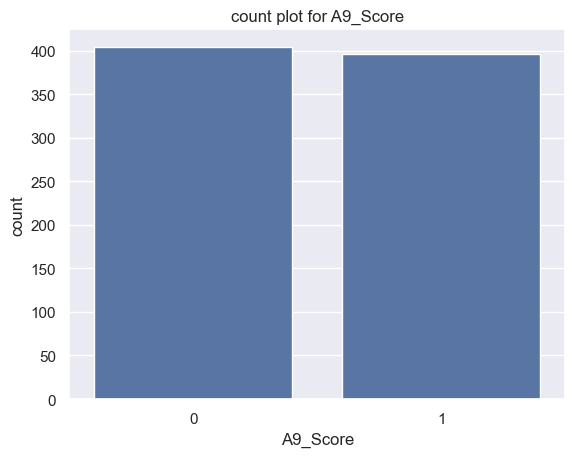

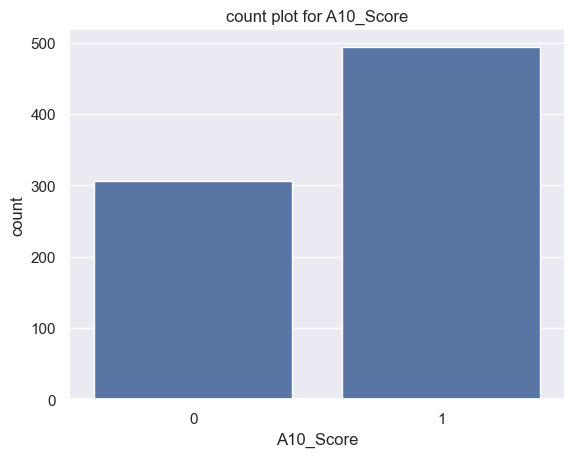

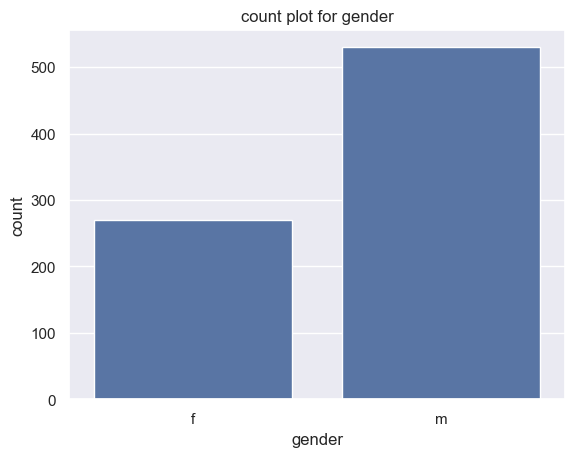

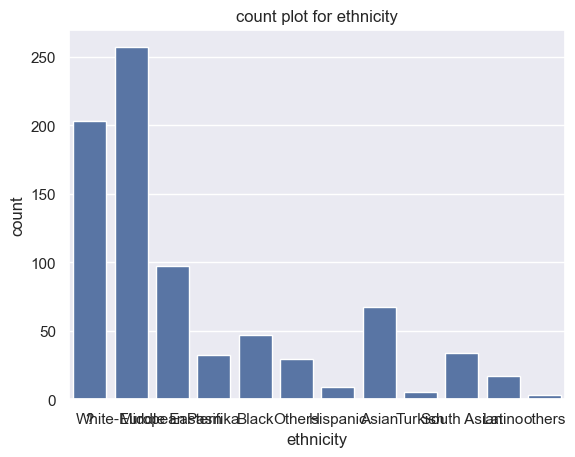

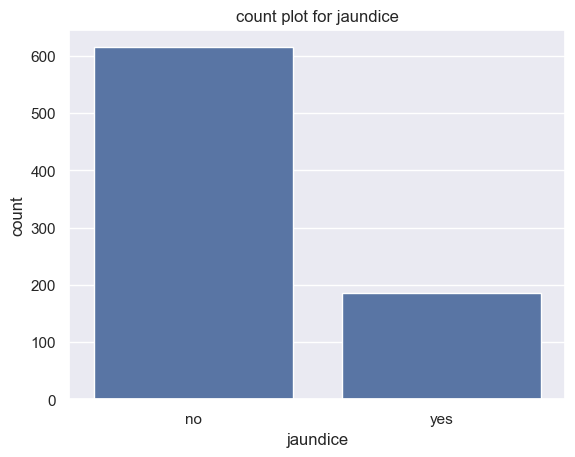

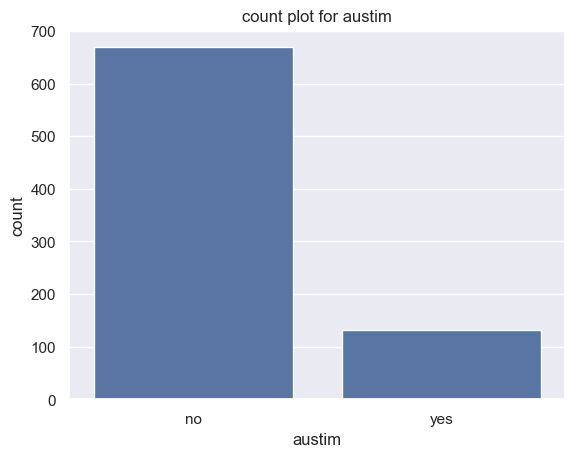

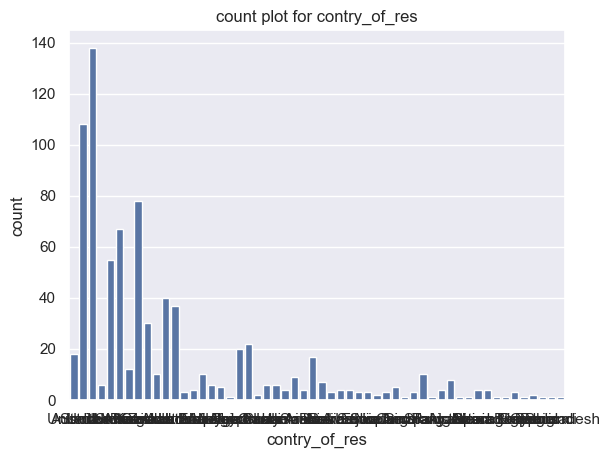

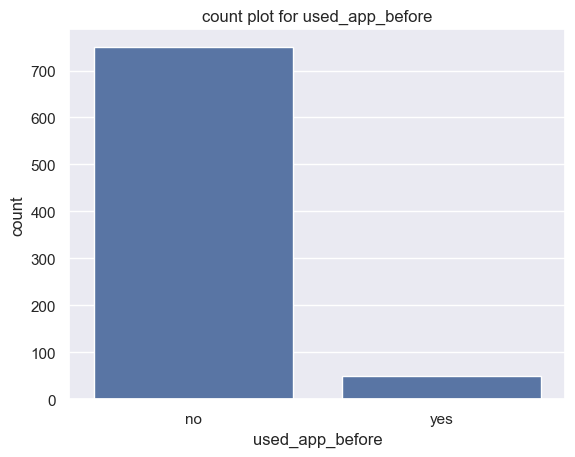

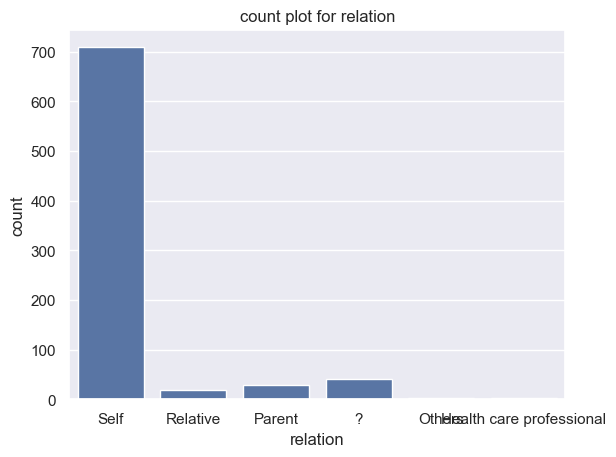

In [39]:
categorical_coloumns=['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
        'relation']
for col in categorical_coloumns:
    sns.countplot(x=df[col])
    plt.title(f"count plot for {col}")
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()

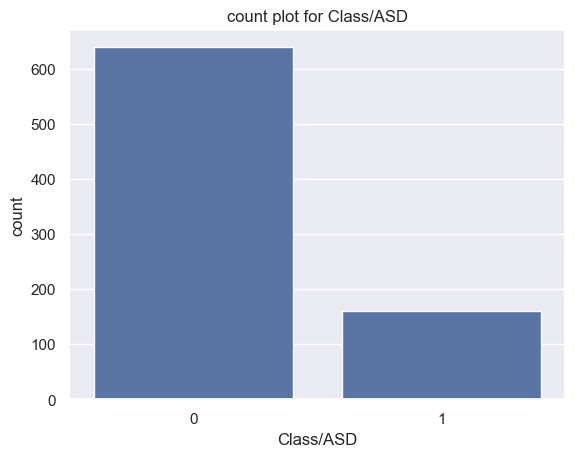

In [40]:
#countplots for target coloum (Class/ASD)
sns.countplot(x=df["Class/ASD"])
plt.title("count plot for Class/ASD")
plt.xlabel("Class/ASD")
plt.ylabel("count")
plt.show()

In [41]:
df["Class/ASD"].value_counts()

Class/ASD
0    639
1    161
Name: count, dtype: int64

handle missing value in ethnicity and relation column

In [42]:
df["ethnicity"] = df["ethnicity"].replace({"?":"Others","others":"Others"})

In [43]:
df["ethnicity"].unique()

<StringArray>
[         'Others',  'White-European', 'Middle Eastern ',        'Pasifika',
           'Black',        'Hispanic',           'Asian',         'Turkish',
     'South Asian',          'Latino']
Length: 10, dtype: str

In [44]:
df["relation"].unique()

<StringArray>
['Self', 'Relative', 'Parent', '?', 'Others', 'Health care professional']
Length: 6, dtype: str

In [45]:
df["relation"]=df["relation"].replace(
    {"?":"Others",
     "Relative":"Others",
     "Parent":"Others",
     "Health care professional":"Others"
     
     }
)

In [46]:
df["relation"].unique()

<StringArray>
['Self', 'Others']
Length: 2, dtype: str

In [47]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38,f,Others,no,no,Austria,no,Self,0
1,0,0,0,0,0,0,0,0,0,0,47,m,Others,no,no,India,no,Self,0
2,1,1,1,1,1,1,1,1,1,1,7,m,White-European,no,yes,United States,no,Self,1
3,0,0,0,0,0,0,0,0,0,0,23,f,Others,no,no,United States,no,Self,0
4,0,0,0,0,0,0,0,0,0,0,43,m,Others,no,no,South Africa,no,Self,0


***Label Encoding***

In [48]:
#identify column with "object " data type 
object_columns = df.select_dtypes(include=["object"]).columns

C:\Users\HP\AppData\Local\Temp\ipykernel_26304\318906979.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = df.select_dtypes(include=["object"]).columns


In [49]:
print(object_columns)

Index(['gender', 'ethnicity', 'jaundice', 'austim', 'contry_of_res',
       'used_app_before', 'relation'],
      dtype='str')


In [50]:
#initialize a dictionary to store the encoders
encoders ={}

# apply lable encoding and store the encoders
for column in object_columns:
    Label_encoder =LabelEncoder()
    df[column] = Label_encoder.fit_transform(df[column])
    encoders[column]=Label_encoder #saving the encoder for the column

    #save the encoder as a pickle file 
    with open ("encoders.pkl","wb")as f:
        pickle.dump(encoders,f)

In [51]:
encoders

{'gender': LabelEncoder(),
 'ethnicity': LabelEncoder(),
 'jaundice': LabelEncoder(),
 'austim': LabelEncoder(),
 'contry_of_res': LabelEncoder(),
 'used_app_before': LabelEncoder(),
 'relation': LabelEncoder()}

In [52]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38,0,5,0,0,6,0,1,0
1,0,0,0,0,0,0,0,0,0,0,47,1,5,0,0,23,0,1,0
2,1,1,1,1,1,1,1,1,1,1,7,1,9,0,1,52,0,1,1
3,0,0,0,0,0,0,0,0,0,0,23,0,5,0,0,52,0,1,0
4,0,0,0,0,0,0,0,0,0,0,43,1,5,0,0,44,0,1,0


Bivariate Analysis

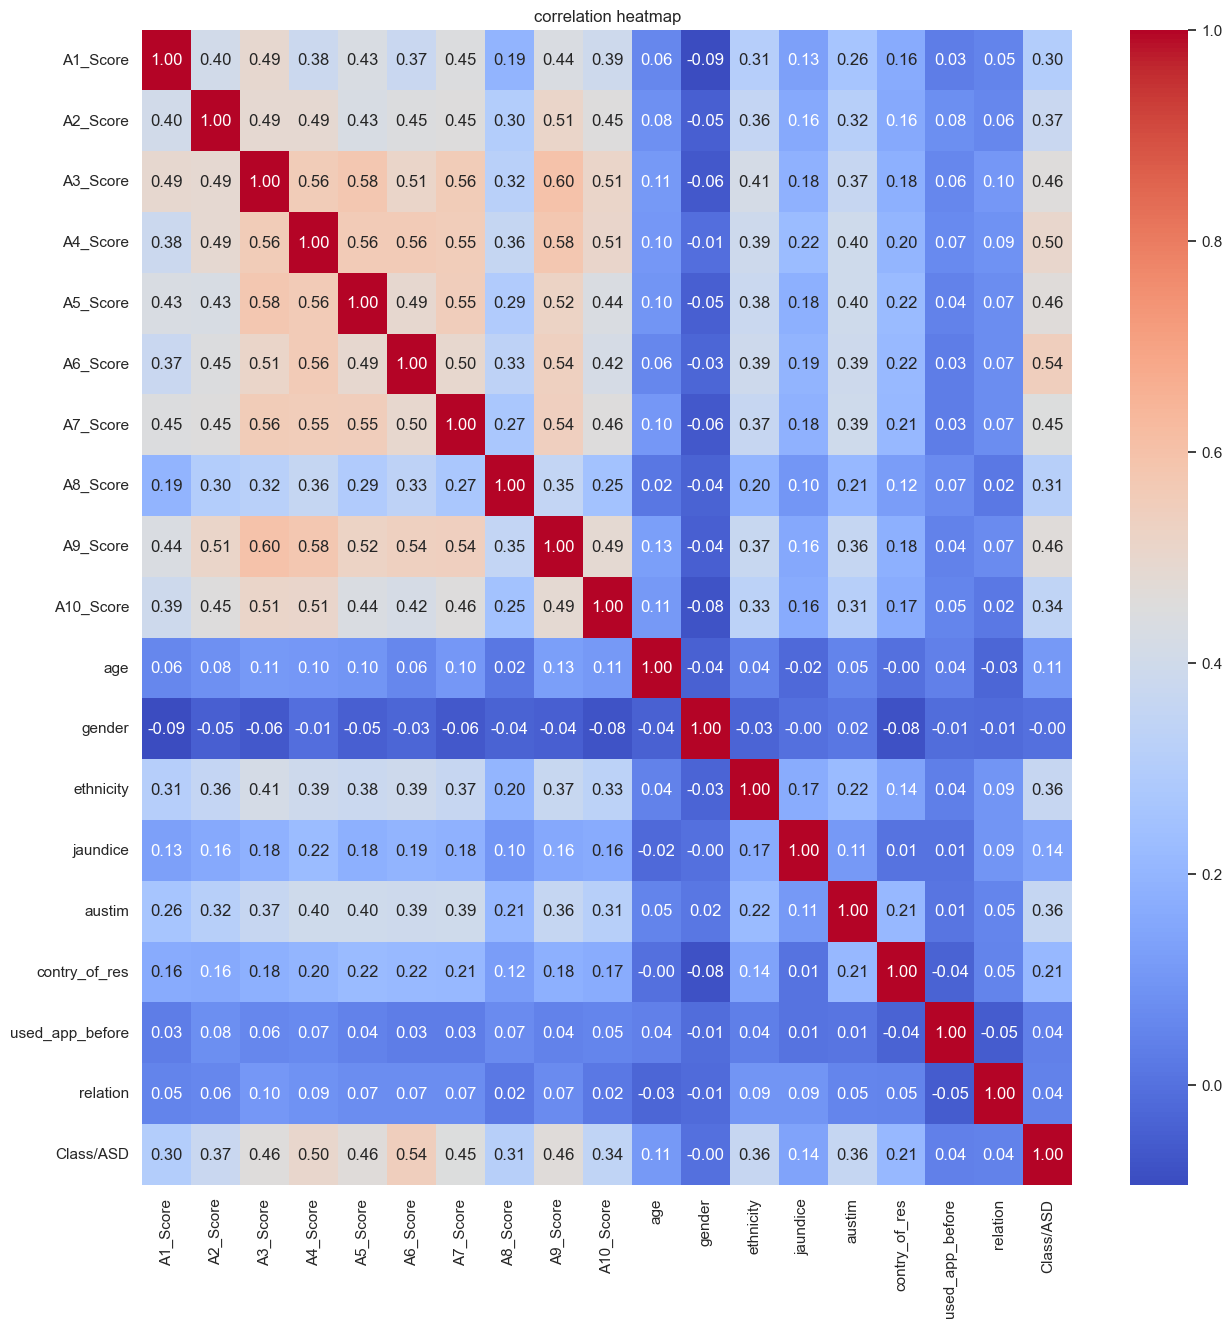

In [53]:
#correlation matrix 
plt.figure(figsize=(15,15))
sns.heatmap(df.corr(),annot=True,cmap="coolwarm",fmt=".2f" )
plt.title("correlation heatmap")
plt.show()

***insight from eda***
- there are few outlires in the numerical column (age,result)
- there is a class imbalance in the categorical features
- we dont ahve any highly correlated column
- performed label encoding and saved the encoders

4. Data preprocessing 

Handling the outliers

In [54]:
#function to replace the oputlires with th median 
def replace_outliers_with_median(df,column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)
    IQR=Q3-Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 +1.5 * IQR

    median = df[column].median()

#replace outliers with median value
    df[column]= df[column].apply(lambda x: median if x < lower_bound or x > upper_bound else x)

    return df

In [55]:
#replace outlier in the "age " column

df= replace_outliers_with_median(df,"age")
#replace outlier in the "result " column

# df= replace_outliers_with_median(df,"result")

In [56]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,age,gender,ethnicity,jaundice,austim,contry_of_res,used_app_before,relation,Class/ASD
0,1,0,1,0,1,0,1,0,1,1,38.0,0,5,0,0,6,0,1,0
1,0,0,0,0,0,0,0,0,0,0,47.0,1,5,0,0,23,0,1,0
2,1,1,1,1,1,1,1,1,1,1,7.0,1,9,0,1,52,0,1,1
3,0,0,0,0,0,0,0,0,0,0,23.0,0,5,0,0,52,0,1,0
4,0,0,0,0,0,0,0,0,0,0,43.0,1,5,0,0,44,0,1,0


In [57]:
df.shape

(800, 19)

Train Test Split

In [58]:
df.columns

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'relation', 'Class/ASD'],
      dtype='str')

In [59]:
x=df.drop(columns=["Class/ASD"])
y=df["Class/ASD"]

In [60]:
print(x)

     A1_Score  A2_Score  A3_Score  A4_Score  A5_Score  A6_Score  A7_Score  \
0           1         0         1         0         1         0         1   
1           0         0         0         0         0         0         0   
2           1         1         1         1         1         1         1   
3           0         0         0         0         0         0         0   
4           0         0         0         0         0         0         0   
5           1         0         0         0         0         1         0   
6           1         0         0         0         0         0         1   
7           1         1         1         1         1         1         1   
8           1         1         1         1         0         0         0   
9           0         0         0         0         0         0         0   
10          1         1         1         1         1         1         1   
11          1         1         0         0         0         1         0   

In [61]:
print(y)

0      0
1      0
2      1
3      0
4      0
5      0
6      0
7      1
8      0
9      0
10     0
11     0
12     0
13     0
14     0
15     0
16     0
17     0
18     0
19     1
20     1
21     0
22     0
23     0
24     0
25     0
26     0
27     0
28     1
29     1
30     1
31     0
32     0
33     0
34     0
35     1
36     0
37     0
38     0
39     0
40     0
41     0
42     1
43     1
44     1
45     0
46     0
47     1
48     0
49     0
50     0
51     0
52     0
53     0
54     0
55     0
56     0
57     0
58     0
59     0
60     0
61     0
62     1
63     0
64     1
65     1
66     0
67     1
68     0
69     0
70     0
71     0
72     0
73     0
74     0
75     1
76     0
77     0
78     0
79     0
80     0
81     0
82     0
83     0
84     1
85     0
86     0
87     0
88     0
89     0
90     0
91     1
92     0
93     0
94     0
95     0
96     0
97     0
98     0
99     0
100    0
101    0
102    0
103    1
104    0
105    0
106    0
107    0
108    0
109    1
110    0
1

In [62]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [63]:
print(y_train.shape)
print(y_test.shape)

(640,)
(160,)


In [64]:
y_train.value_counts()

Class/ASD
0    515
1    125
Name: count, dtype: int64

In [65]:
y_test.value_counts()

Class/ASD
0    124
1     36
Name: count, dtype: int64

SMOTE(Synthetic Minority Oversampling technique)

In [66]:
smote =  SMOTE(random_state=42)
x_train_smote,y_train_smote = smote.fit_resample(x_train,y_train)

In [67]:
print (y_train_smote.shape)

(1030,)


In [68]:
print (y_train_smote.value_counts())

Class/ASD
1    515
0    515
Name: count, dtype: int64


5. Modle Training

In [69]:
# list of classifiers

models  ={
    "Decision Tree" : DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42)
}

In [70]:
# dictionary to store the cross validation results
cv_scores = {}

#perform 5_fold cross validation for each model
for model_name, model in models.items():
    print(f"Training {model_name} with default parameters...")
    scores = cross_val_score(model,x_train_smote, y_train_smote, cv=5, scoring="f1")
    cv_scores[model_name]=scores
    print(f"{model_name} Cross-validation Accuracy: {np.mean(scores ):.2f}")
    print("-"*50)

Training Decision Tree with default parameters...
Decision Tree Cross-validation Accuracy: 0.86
--------------------------------------------------
Training Random Forest with default parameters...
Random Forest Cross-validation Accuracy: 0.92
--------------------------------------------------
Training XGBoost with default parameters...
XGBoost Cross-validation Accuracy: 0.91
--------------------------------------------------


In [71]:
cv_scores

{'Decision Tree': array([0.77486911, 0.8952381 , 0.89686099, 0.89622642, 0.85581395]),
 'Random Forest': array([0.90140845, 0.9478673 , 0.93636364, 0.91324201, 0.92307692]),
 'XGBoost': array([0.85      , 0.94835681, 0.92792793, 0.94009217, 0.9058296 ])}

6. Model selection & Hyperparameter Tuning

In [72]:
# initialization models
decision_tree = DecisionTreeClassifier(random_state=42)
random_forest= RandomForestClassifier(random_state=42)
xgboost_classifier= XGBClassifier(random_state=42)



In [73]:
#hyperparameter grids for randomizedSearchCV

param_grid_dt={
    "criterion": ["gini","entropy"],
    "max_depth":[None, 10, 20, 30, 50, 70],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4]
}
param_grid_rf={
    "n_estimators": [50,100,200,500],
    "max_depth":[None, 10, 20, 30],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4],
    "bootstrap":[True,False]
}

param_grid_xgb={
    "n_estimators": [50,100,200,500],
    "max_depth":[None, 10, 20, 30],
    "learning_rate":[0.01,0.1,0.2,0.3],
    "subsample":[0.5,0.7,1.0],
    "colsample_bytree":[0.5,0.7,1.0]
}

In [74]:
#hyperparameter tuning for 3 tree base models


# the below steps can be  automated by using a for loop or by using a pipeline

# perform Randomizedsearchcv for each model

random_search_dt = RandomizedSearchCV(estimator=decision_tree,param_distributions=param_grid_dt,n_iter=20,cv=5,scoring="accuracy",random_state=42)
random_search_rf = RandomizedSearchCV(estimator=random_forest,param_distributions=param_grid_rf,n_iter=20,cv=5,scoring="accuracy",random_state=42)
random_search_xgb = RandomizedSearchCV(estimator=xgboost_classifier,param_distributions=param_grid_xgb,n_iter=20,cv=5,scoring="accuracy",random_state=42)


In [75]:
#fit the models
random_search_dt.fit(x_train_smote, y_train_smote)
random_search_rf.fit(x_train_smote, y_train_smote)
random_search_xgb.fit(x_train_smote, y_train_smote)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.5, 0.7, ...], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [None, 10, ...], 'n_estimators': [50, 100, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can 

In [76]:
print(random_search_dt.best_estimator_)
print(random_search_dt.best_score_)
print(random_search_rf.best_estimator_)
print(random_search_rf.best_score_)

DecisionTreeClassifier(criterion='entropy', max_depth=10, min_samples_leaf=2,
                       min_samples_split=5, random_state=42)
0.8747572815533982
RandomForestClassifier(bootstrap=False, max_depth=10, random_state=42)
0.9223300970873787


In [77]:
#get the model with best scores 

best_model=None
best_scores = 0

if random_search_dt.best_score_>best_scores:
    best_model = random_search_dt.best_estimator_
    best_scores = random_search_dt.best_score_

if random_search_rf.best_score_>best_scores:
    best_model = random_search_rf.best_estimator_
    best_scores = random_search_rf.best_score_
     
if random_search_xgb.best_score_>best_scores:
    best_model = random_search_xgb.best_estimator_
    best_scores = random_search_xgb.best_score_

In [78]:
print(f"best_model: {best_model}")
print(f"bets cross-validation accuracy: {best_scores:.2f}" )

best_model: RandomForestClassifier(bootstrap=False, max_depth=10, random_state=42)
bets cross-validation accuracy: 0.92


In [79]:
#save the best model
with open("best_model.pkl","wb") as f:
    pickle.dump(best_model,f)

7. Evaluation

In [80]:
#evaluate on the test data
y_test_pred = best_model.predict(x_test)
print("accuracy_score:\n", accuracy_score(y_test,y_test_pred))
print("confusion matrix:\n", confusion_matrix(y_test,y_test_pred))
print("classification Report\n", classification_report(y_test,y_test_pred))

accuracy_score:
 0.8375
confusion matrix:
 [[108  16]
 [ 10  26]]
classification Report
               precision    recall  f1-score   support

           0       0.92      0.87      0.89       124
           1       0.62      0.72      0.67        36

    accuracy                           0.84       160
   macro avg       0.77      0.80      0.78       160
weighted avg       0.85      0.84      0.84       160



***To do:***

1. build a predictictive system with encoder and the model file 
2. see if you could improve the preformance 

In [81]:
encoders["gender"].classes_

array(['f', 'm'], dtype=object)

In [82]:
x.shape

(800, 18)

In [83]:
print(x.columns)

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'relation'],
      dtype='str')


In [84]:
len(x.columns)

18

In [85]:
pickle.dump(x.columns, open("columns.pkl","wb"))

In [86]:
print(x.columns)

Index(['A1_Score', 'A2_Score', 'A3_Score', 'A4_Score', 'A5_Score', 'A6_Score',
       'A7_Score', 'A8_Score', 'A9_Score', 'A10_Score', 'age', 'gender',
       'ethnicity', 'jaundice', 'austim', 'contry_of_res', 'used_app_before',
       'relation'],
      dtype='str')


In [87]:
df["ethnicity"].unique()

array([5, 9, 4, 6, 1, 2, 0, 8, 7, 3])

In [88]:
df["contry_of_res"].unique()

array([ 6, 23, 52, 44, 29, 51, 12, 34, 14, 30, 50,  5, 49, 25, 20, 31, 53,
       18, 33,  0, 37, 27,  8, 41, 26,  4, 46, 40, 11,  7,  3, 42, 19, 47,
       22, 15,  1, 21, 45, 48, 38, 24,  2, 28, 32, 35, 43, 17, 36, 39, 16,
       10, 13,  9])